# Coursework 2: Generative Models

#### Instructions

Please submit on CATe a zip file named *CW2.zip* containing the following:
1. A version of this notebook containing your answers. Write your answers in the cells below each question.
2. Your trained models as *VAE_model.pth, DCGAN_model_D.pth, DCGAN_model_G.pth*

#### Working environment:

Similarly to the previous coursework, we recommend that you use Google Colaboratory in order to train the required networks.

**The deadline for submission is 19:00, Thursday 27th February, 2020**

### Setting up working environment

For this coursework you, will need to train a large network, therefore we recommend you work with Google Colaboratory, which provides free GPU time. You will need a Google account to do so.

Please log in to your account and go to the following page: https://colab.research.google.com. Then upload this notebook.

For GPU support, go to "Edit" -> "Notebook Settings", and select "Hardware accelerator" as "GPU".

You will need to install pytorch by running the following cell:

In [0]:
!pip install torch torchvision

In [0]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
cd /content/drive/"My Drive"/"Colab Notebooks"/"Deep Learnign"/"cw_2"

/content/drive/My Drive/Colab Notebooks/Deep Learnign/cw_2


## Introduction

For this coursework, you are asked to implement two commonly used generative models:
1. A **Variational Autoencoder (VAE)**
2. A **Deep Convolutional Generative Adversarial Network (DCGAN)**

For the first part you will the MNIST dataset https://en.wikipedia.org/wiki/MNIST_database and for the second the CIFAR-10 (https://www.cs.toronto.edu/~kriz/cifar.html).

## Part 1 (50 points)
1. For the first part, you are asked to implement a Variational Autoencoder on the MNIST dataset. You will be assesed by the following:
    - **loss function and proper explanations**. You will have to choose the right loss function by properly modelling the probability distribution of the input pixels. There are more than one accepted approaches. 
    - **reconstruction error**. You will need to achieve a low enough error in order to reconstruct the images of the dataset with relatively high fidelity. You will have to provide us with your best model's training and test loss curves (both the total loss and each individual term), a few reconstructed images and a few sampled images from the latent space of the VAE in the respective cells.
    - **qualitative results**. You have to provide us with certain qualitative results that are usually used to assess the quality of the learned representations (more info below)

 
## Part 2 (50 points)
2. For the DCGAN, The success of your models will be tested as follows:
    - **By the model's training error**. You will need to achieve relatively balanced errors for the generator and the discriminator of your model in order to sample realistic images from the generator. You will have to provide us with your best model's training losses curves, a discussion on how you concluded to the chosen architecture, and visualizations of generated samples in the respective cells. Your results do not have to be perfect, however a good discussion on the choice of architecture will be valued.
    - **By avoiding mode collapse**. A common problem of training GANs is that they end up generating only a few different samples (if not only one), rather than learning the whole distribution of the training data. This problem is referred to as mode collapse. You will need to make a discussion on whether you noticed mode collapse or not during your experimentation and if yes, how you addressed it.

# Part 1 - Variational Autoencoder

## Part 1.1 (25 points)
**Your Task:**

a. Implement the VAE architecture. You are free to choose either Multilayer Perceptrons (MLPs) or Convolutional Layers

You will need to define:
*  The hyperparameters
* The constructor
* encode
* reparametrize
* decode
* forward

b. Design an appropriate loss function. There are multiple accepted solutions. Explain your design choices based on the assumptions you make regarding the distribution of your data.

* Hint: this refers to the log likelihood as mentioned in the tutorial. Make sure these assumptions reflect on the values of your input data, i.e. depending on your choice you might need to do a simple preprocessing step.

* You are encouraged to experiment with the weighting coefficient $\beta$ and observe how it affects your training.


In [0]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import sampler
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import torch.nn.functional as F
import matplotlib.pyplot as plt


def show(img):
    if torch.cuda.is_available():
        img = img.cpu()
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))

# device selection
GPU = True
device_idx = 0
if GPU:
    device = torch.device("cuda:" + str(device_idx) if torch.cuda.is_available() else "cpu")
else:
    device = torch.device("cpu")
print(device)

# We set a random seed to ensure that your results are reproducible.
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
torch.manual_seed(0)

if not os.path.exists('./CW_VAE/MNIST'):
    os.makedirs('./CW_VAE/MNIST')


cuda:0


## Hyper-parameter selection

In [0]:
# *CODE FOR PART 1.1 IN THIS CELL*

### Choose the number of epochs, the learning rate and the batch size
num_epochs = 20
learning_rate  = 0.001
batch_size = 64
### Choose a value for the size of the latent space
latent_dim = 40

###

# Define here the any extra hyperparameters you used.

###

# Modify this line if you need to do any input transformations (optional).
transform = transforms.Compose([
     transforms.ToTensor(),
])

# Modify the denorm function in case you need to do any output transformation when visualizing your images

denorm = lambda x:x



## Data loading


In [0]:
train_dat = datasets.MNIST(
    "data/", train=True, download=True, transform=transform
)
test_dat = datasets.MNIST("data/", train=False, transform=transform)

loader_train = DataLoader(train_dat, batch_size, shuffle=True)
loader_test = DataLoader(test_dat, batch_size, shuffle=False)

sample_inputs, _ = next(iter(loader_test))
fixed_input = sample_inputs[:32, :, :, :]

save_image(fixed_input, './CW_VAE/MNIST/image_original.png')

## Model Definition

In [0]:
# *CODE FOR PART 1.1a IN THIS CELL*


class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################
    
        # len(enc_layers_sizes) - 1 = number of encoder linear layers 
        self.enc_layers_sizes = [28 * 28, 256]
        # len(dec_layers_sizes) - 1 = number of decoder linear layers
        self.dec_layers_sizes = [latent_dim] + [256, 28 * 28]
        
        # Define the Encoder
        self.encoder = nn.Sequential(nn.Flatten())
        for i, (in_dims, out_dims) in enumerate(zip(
            self.enc_layers_sizes[:-1], self.enc_layers_sizes[1:])):

            self.encoder.add_module(
                name=f'Linear {i}',module=nn.Linear(in_dims, out_dims))
            self.encoder.add_module(name='Activation', module=nn.ReLU())
        # Fully Connected layers for mu and log-variance
        self.fc_mean = nn.Linear(self.enc_layers_sizes[-1], latent_dim) 
        self.fc_logvar = nn.Linear(self.enc_layers_sizes[-1], latent_dim)
        
        # Define the Decoder
        self.decoder = nn.Sequential()
        for i, (in_dims, out_dims) in enumerate(
            zip(self.dec_layers_sizes[:-1], self.dec_layers_sizes[1:])):
            self.decoder.add_module(
                name=f'Linear {i}', module=nn.Linear(in_dims, out_dims))
            if i+2 < len(self.dec_layers_sizes):
                self.decoder.add_module(name='Activation', module=nn.ReLU()) # Add ReLU to all linear layers except the last
            else:
                self.decoder.add_module(name="Sigmoid", module=nn.Sigmoid()) # Add a Sigmoid to last linear layer


        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 
        
        
    def encode(self, x):
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################

        x = self.encoder(x)

        mu = self.fc_mean(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 
    
    def reparametrize(self, mu, logvar):
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################
        
        std = torch.exp(logvar / 2)
        epsilon = torch.randn_like(std)

        return mu + epsilon * std

        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 

        
    def decode(self, z):
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################
        
        z = self.decoder(z)

        return z

        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 

    
    def forward(self, x):
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################
        mu , logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        recon_input = self.decode(z)

        return recon_input, mu, logvar
        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 

    
model = VAE(latent_dim=latent_dim).to(device)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total number of parameters is: {}".format(params))
print(model)
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Total number of parameters is: 433504
VAE(
  (encoder): Sequential(
    (0): Flatten()
    (Linear 0): Linear(in_features=784, out_features=256, bias=True)
    (Activation): ReLU()
  )
  (fc_mean): Linear(in_features=256, out_features=40, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=40, bias=True)
  (decoder): Sequential(
    (Linear 0): Linear(in_features=40, out_features=256, bias=True)
    (Activation): ReLU()
    (Linear 1): Linear(in_features=256, out_features=784, bias=True)
    (Sigmoid): Sigmoid()
  )
)


## Training loop

In [0]:
# *CODE FOR PART 1.1b IN THIS CELL*

def loss_function_VAE(x_samp, x, mu, logvar):
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################
        reconstruct_loss = F.binary_cross_entropy(x_samp, x.view(-1, 28 * 28), reduction='sum')
        kl_divergence = torch.sum(torch.exp(logvar) + mu**2 -logvar - 1.0) / 2

        return reconstruct_loss, kl_divergence
        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 

model.train()
losses = []
train_loglike_losses = []
train_kl_losses = []

valid_losses = []
valid_loglike_losses = []
valid_kl_losses = []
for epoch in range(num_epochs):     
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################
    # Store losses to plot
    
    # loss of the epoch
    model.train()
    train_loss, train_loglike_loss, train_kl_loss = 0.0, 0.0, 0.0
    for batch_idx, (img, _) in enumerate(loader_train):
        #img = img.view(16, 1, 28, 28)
        
        img = img.to(device)

        optimizer.zero_grad()
        # forward
        x_samp, mu, logvar = model(img)
        
        loglike_loss, kl_div = loss_function_VAE(x_samp, img, mu, logvar)

        loss = (loglike_loss + kl_div) / img.shape[0]
        # backward
        loss.backward()
        train_loss += loss.item()
        train_loglike_loss += loglike_loss / img.shape[0]
        train_kl_loss += kl_div / img.shape[0]
        optimizer.step()

    valid_loss, valid_loglike_loss, valid_kl_loss = 0.0, 0.0, 0.0
    model.eval()
    with torch.no_grad():
        for batch_idx, (img, _) in enumerate(loader_test):
            
            img = img.to(device)

            optimizer.zero_grad()
            # forward
            x_samp, mu, logvar = model(img)

            loglike_loss, kl_loss = loss_function_VAE(x_samp, img, mu, logvar)

            loss = (loglike_loss + kl_loss) / img.shape[0]
            valid_loss += loss.item()
            valid_loglike_loss += loglike_loss / img.shape[0]
            valid_kl_loss += kl_loss / img.shape[0]

    
    print('epoch [{}/{}], Training loss:{:.4f}, Validation loss:{:.4f}'.format(
        epoch + 1, 
        num_epochs, 
        train_loss / len(loader_train.dataset),
        valid_loss / len(loader_test.dataset))
    )

    losses.append(train_loss / len(loader_train.dataset))
    train_loglike_losses.append(train_loglike_loss / len(loader_train.dataset))
    train_kl_losses.append(train_kl_loss / len(loader_train.dataset))   

    valid_losses.append(valid_loss / len(loader_test.dataset))
    valid_loglike_losses.append(valid_loglike_loss / len(loader_test.dataset))
    valid_kl_losses.append(valid_kl_loss / len(loader_test.dataset))




        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 


# save the model 
torch.save(model.state_dict(), './CW_VAE/MNIST/VAE_model.pth')

epoch [1/20], Training loss:2.5221, Validation loss:2.0455
epoch [2/20], Training loss:1.9351, Validation loss:1.8431
epoch [3/20], Training loss:1.8048, Validation loss:1.7637
epoch [4/20], Training loss:1.7518, Validation loss:1.7273
epoch [5/20], Training loss:1.7235, Validation loss:1.7095
epoch [6/20], Training loss:1.7056, Validation loss:1.6956
epoch [7/20], Training loss:1.6941, Validation loss:1.6836
epoch [8/20], Training loss:1.6840, Validation loss:1.6738
epoch [9/20], Training loss:1.6769, Validation loss:1.6703
epoch [10/20], Training loss:1.6712, Validation loss:1.6704
epoch [11/20], Training loss:1.6660, Validation loss:1.6637
epoch [12/20], Training loss:1.6619, Validation loss:1.6616
epoch [13/20], Training loss:1.6578, Validation loss:1.6574
epoch [14/20], Training loss:1.6545, Validation loss:1.6541
epoch [15/20], Training loss:1.6522, Validation loss:1.6515
epoch [16/20], Training loss:1.6494, Validation loss:1.6491
epoch [17/20], Training loss:1.6465, Validation l

### Your explanations about the loss function here:

Our task is to maximise the (log-) likelihood of the original input $x^{(i)}$ of being reconstructed, or equivalently, minimise the neg-log-likelihood $\bigg(\mathbb{E_{z\sim q_{\phi}(z|x^{(i)})} }[\log p_{\theta} (x^{(i)},z) ] \bigg)$ and also to minimise the  KL -divergence between  $q_ϕ(z|x(i))$  and  $p_θ(z)$  $\bigg(D_{KL} (q_{\theta}(z|x^{(i)}) || p_\theta(z)) = -\frac{1}{2} \sum_{j=1}^J 1+\log(\sigma_{ij}^2)-\mu_{ij}^2-\sigma_{ij}^2\bigg)$, or in other words make sure that the approximation $ p_θ(z) $ of the posterior $ p(z|x^{(i)}) $ becomes/stays closer to the prior distribution.


Therefore, we choose as a loss function the sum of the two terms:


```
reconstruct_loss = F.binary_cross_entropy(x_samp, x.view(-1, 28 * 28),  1.0) / 2
```
and
```
kl_divergence = torch.sum(torch.exp(logvar) + mu**2 -logvar - 1.0) / 2
```



## Part 1.2 (10 points)

a. Plot your loss curves (6 in total, 3 for the training set and 3 for the test set): total loss, reconstruction log likelihood loss, KL loss (x-axis: epochs, y-axis: loss). 

b. Provide a brief analysis of your loss curves. What do you observe in the behaviour of the log-likelihood loss and the KL loss (increasing/decreasing)? Can you intuitively explain if this behaviour is desirable? Have you observed posterior collapse during traing (i.e. when the KL is too small during the early stages of training)? If yes, how did you mitigate it? How did this phenomenon reflect on your output samples? 

c. Visualize a subset of the images of the test set and their reconstructions as well as a few generated samples. Most of the code for this part is provided. You only need to call the forward pass of the model for the given inputs (might vary depending on your implementation) .Please deliver the notebook including the outputs of the cells below.


Text(0.5, 1.0, 'KL Divergence Loss')

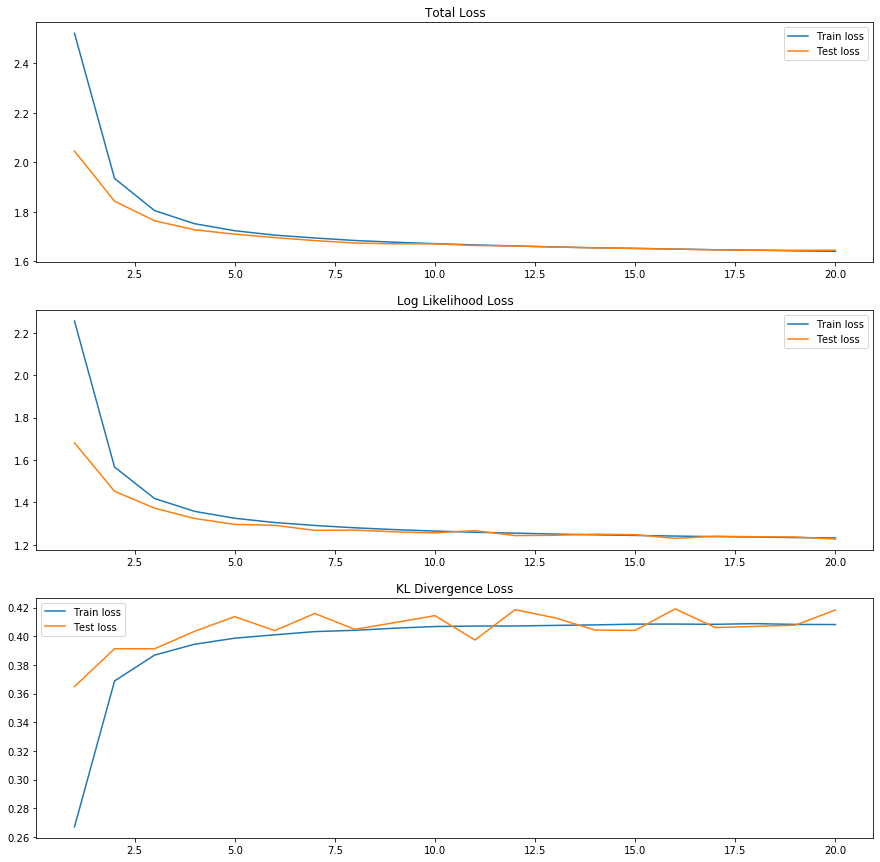

In [0]:
# *CODE FOR PART 1.2a IN THIS CELL*
fig, axs = plt.subplots(3, 1, figsize=(15,15))
axs[0].plot(list(range(1, 1 + len(losses))), losses)
axs[0].plot(list(range(1, 1 + len(valid_losses))), valid_losses)
axs[0].legend(['Train loss', 'Test loss'])
axs[0].set_title('Total Loss')

axs[1].plot(list(range(1, 1 + len(train_loglike_losses))), train_loglike_losses)
axs[1].plot(list(range(1, 1 + len(valid_loglike_losses))), valid_loglike_losses)
axs[1].legend(['Train loss', 'Test loss'])
axs[1].set_title('Log Likelihood Loss')

axs[2].plot(list(range(1, 1 + len(train_kl_losses))), train_kl_losses)
axs[2].plot(list(range(1, 1 + len(valid_kl_losses))), valid_kl_losses)
axs[2].legend(['Train loss', 'Test loss'])
axs[2].set_title('KL Divergence Loss')

***********
### Your answer to 1.2b here:

Above they are plotted the graphs of the total loss, the reconstruction (negative) log likelihood loss and KL-divergence loss of both, the training and test sets. As it can be seen from the first plot, and as expected, the total loss in both cases is decreasing after every epoch. Observing the second plot, we can see that similarilly to the total loss, the reconstruction log likelihood loss also drops after each epoch. However, observing the thrird graph, in contrast to the other losses, the KL-divergence loss increases during the first 5-10 epochs and then stabilises.


Our task is to maximise our objective function , i.e: $$ \max_{\theta, \phi} L(x^{(i)},\theta, \phi) = \mathbb{E_{z\sim q_{\phi}(z|x^{(i)})} }[\log p_{\theta} (x^{(i)},z) ] - D_{KL} (q_{\theta}(z|x^{(i)}) || p_\theta(z))$$ or equivalently to minimise $ - L(x^{(i)},\theta, \phi) $, i.e:
 $$ \min_{\theta, \phi} - L(x^{(i)},\theta, \phi) = - \mathbb{E_{z\sim q_{\phi}(z|x^{(i)})} }[\log p_{\theta} (x^{(i)},z) ] + D_{KL} (q_{\theta}(z|x^{(i)}) || p_\theta(z))$$ (since optimisers in Machine Learning minimise functions).

Therefore, the above results are desirable and expected;
1. The negative log-likelihood dropping means that the log-likelihood increases. Hence, since we want to maximise the (log-) likelihood of the original input ($x^{(i)}$) of being reconstructed, the neg-log-likelihood decreasing is a desirable outcome.

2. Since we want to minimise the $KL$-divergence between $q_{\phi}(z|x^{(i)})$ and $p_\theta(z)$ (which acts as a regularization term), or in other words make sure that the approximation ($p_\theta(z)$) of the posterior ($p(z|x^{(i)})$) becomes/stays closer to the prior distribution. Since, the KL-divergence loss is initially increasing and then non-decreasing, we have the desired outcome.

When KL is too small during the early stages of training or when training for very few (2-3) epochs, output samples are just random pixeladed pictures. That's why the training implemented here ws done over 10 or 20 epochs.

***********

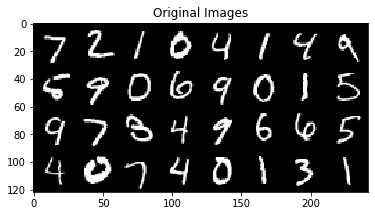

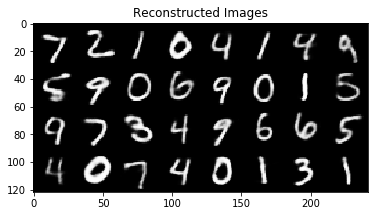

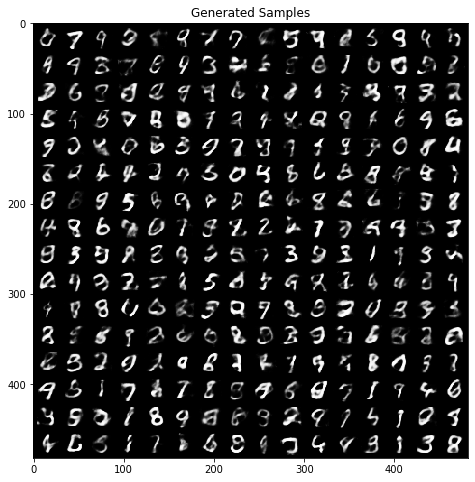

In [0]:
# *CODE FOR PART 1.2c IN THIS CELL*

# load the model
model.load_state_dict(torch.load('./CW_VAE/MNIST/VAE_model.pth'))
sample_inputs, _ = next(iter(loader_test))
fixed_input = sample_inputs[0:32, :, :, :]

# visualize the original images of the last batch of the test set
img = make_grid(denorm(fixed_input), nrow=8, padding=2, normalize=False,
                range=None, scale_each=False, pad_value=0)

plt.figure()
plt.title('Original Images')
show(img)

with torch.no_grad():
    # visualize the reconstructed images of the last batch of test set
    
    #######################################################################
    #                       ** START OF YOUR CODE **
    #######################################################################
    recon_batch, _, _ = model(fixed_input.to(device))
    recon_batch = recon_batch.view(-1, 1, 28, 28)
    #######################################################################
    #                       ** END OF YOUR CODE **
    ####################################################################### 
    
    recon_batch = recon_batch.cpu()
    recon_batch = make_grid(recon_batch, nrow=8, padding=2, normalize=False,
                            range=None, scale_each=False, pad_value=0)
    plt.figure()
    plt.title('Reconstructed Images')
    show(recon_batch)
    
model.eval()
n_samples = 256
z = torch.randn(n_samples,latent_dim).to(device)
with torch.no_grad():
    #######################################################################
    #                       ** START OF YOUR CODE **
    #######################################################################
    samples = model.decode(z).view(-1, 1, 28, 28)
    #######################################################################
    #                       ** END OF YOUR CODE **
    ####################################################################### 
    
    samples = samples.cpu()
    samples = make_grid(denorm(samples), nrow=16, padding=2, normalize=False,
                            range=None, scale_each=False, pad_value=0)
    plt.figure(figsize = (8,8))
    plt.title('Generated Samples')
    show(samples)



## Part 1.3 (15 points)

### Qualitative analysis of the learned representations

In this question you are asked to qualitatively assess the representations that your model has learned. In particular:

a. Extract the latent representations of the test set and visualize them using T-SNE (https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding, https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) or PCA. What do you observe? Discuss the structure of the visualized representations. Please use different colours for each digit class.

b. Perform a linear interpolation in the latent space of the autoencoder by choosing any two digits from the test set. What do you observe regarding the transition from on digit to the other?

In [0]:
# *CODE FOR PART 1.3a IN THIS CELL*

from sklearn.manifold import TSNE
from matplotlib import offsetbox

def plot_embedding(X, title):
    x_min, x_max = np.min(X, 0), np.max(X, 0)
    X = (X - x_min) / (x_max - x_min)

    plt.figure(figsize=(9,9))
    ax = plt.subplot()
    ax.margins(0.05,0.05)
    for i in range(X.shape[0]):
        plt.plot(X[i, 0], X[i, 1],  marker='s', color=plt.cm.Paired(y[i]/10.))
    if hasattr(offsetbox, 'AnnotationBbox'):
        shown_images = np.array([[1., 1.]]) 
        for i in range(X.shape[0]):
            dist = np.sum((X[i] - shown_images) ** 2, 1)
            if np.min(dist) < 4e-3:
                # don't show points that are too close
                continue
            shown_images = np.r_[shown_images, [X[i]]]
            imagebox = offsetbox.AnnotationBbox(
                offsetbox.OffsetImage(test.reshape(-1, 28, 28)[i,:,:], cmap='gray',zoom=0.7),X[i])
            ax.add_artist(imagebox)
    plt.title(title)

In [0]:
# Load saved model
model.load_state_dict(torch.load('./CW_VAE/MNIST/VAE_model.pth'))

test, X, y = None, None, None
model.eval()
with torch.no_grad():
    # Load test digits and labels
    for batch_idx, data in enumerate(loader_test):
        img, labels = data
        img = img.view(img.size(0), -1) # Data
        img = img.to(device)
        mu, _ = model.encode(img) # Latent features (mu) 
        test = np.concatenate((test, img.cpu().numpy())) if test is not None else img.cpu().numpy()
        X = np.concatenate((X, mu.cpu().numpy())) if X is not None else mu.cpu().numpy()
        y = np.concatenate((y, labels)) if y is not None else labels

# Performing T-SNE using sklearn
tsne = TSNE(n_components=2, random_state=1000, init='pca')
tsne_results = tsne.fit_transform(X)



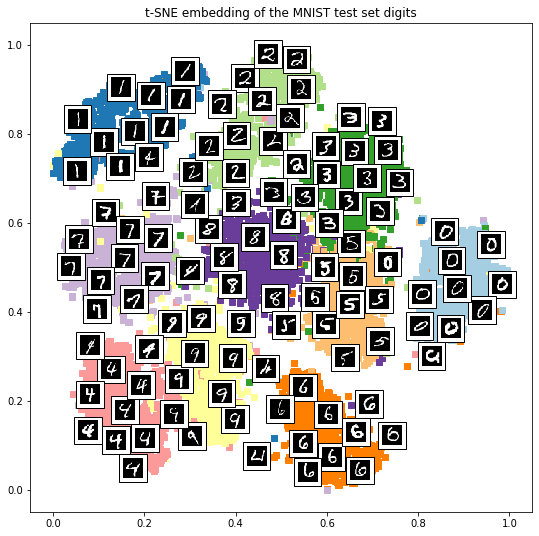

In [0]:
# Plotting tsne results using this defined function
plot_embedding(tsne_results,"t-SNE embedding of the MNIST test set digits" )

### Your answer to 1.3a here:

In the above image, I used t-sne  to visualise the latent representations (mu) of the test set. What actually t-sne does, is to project the latend data (of dimension 40) to a much lower dimensional space (2-D), while at the same time retains most of the information. As we can see from the picture above, the test data are actually clustered into 10 clusters in the 2-dimensional space! That means that indeed the t-sne algorithm succeeded in reducing by 38 dimensions the latent representations of the test data, whilst it managed to keep the important (2-D) features that distinguish one digit from an other!

Interpolation of 9 and 3

--------------------------


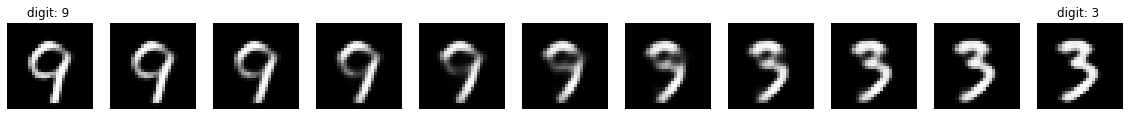

In [0]:
# *CODE FOR PART 1.3b IN THIS CELL*
model.load_state_dict(torch.load('./CW_VAE/MNIST/VAE_model.pth'))
test_data, test_labels = next(iter(loader_test))

# Interpolation of 0 and 9
x1 = torch.FloatTensor(test_data[30]).reshape(1,1,28,28) # 3
x2 = torch.FloatTensor(test_data[16]).reshape(1,1,28,28) # 9

# Create the latent representations
with torch.no_grad():
    x1 = x1.to(device)
    x2 = x2.to(device)
    mu1, var1 = model.encode(x1)
    mu2, var2 = model.encode(x2)
    z1 = model.reparametrize(mu1, var1)
    z2 = model.reparametrize(mu2, var2)
    a = np.linspace(0,1,num=11)
    interpolated = []
    # Interpolation
    for i in range(len(a)):
        Z = a[i] * z1 + (1-a[i]) * z2 
        X_hat = model.decode(Z)
        interpolated.append(X_hat)

# Plot interpolated

fig, axs = plt.subplots(1, 11, figsize=(20,30))
print('Interpolation of {} and {}\n'.format(test_labels[16],test_labels[30]))
print("--------------------------")
for i in range(11):
    y = interpolated[i].view(28,28).squeeze().squeeze().cpu().numpy()
    axs[i].imshow(y, cmap='gray')
    axs[i].axis('off')
    if i == 0:
        axs[i].set_title('digit: {} '.format(test_labels[16]))
    elif i == 10:
        axs[i].set_title('digit: {} '.format(test_labels[30]))

### Your answer to 1.3b here:

In the above illutstration I interpolated two digits from the test set, 9 and 3. On the leftmost picture a 'clear' 9 is plotted and on the righmost a 'clear' 3 is plotted. The intermidiate pictures show the interpolation of the two digits with step 0.1, i.e, the 6th picture is actually composed equally by both digits, and also looks like both digits. 

Observing the figure, we can notice the transition from the first digit to the second digit as their features (edges, curves, etc) are interpolated. Pictures closer to each digit look more similar to that digit, whilst pictures in the center look like both digits.


## Part 2 - Deep Convolutional GAN

In this task, your main objective is to train a DCGAN (https://arxiv.org/abs/1511.06434) on the CIFAR-10 dataset. You should experiment with different architectures, tricks for stability in training (such as using different activation functions, batch normalization, different values for the hyper-parameters, etc.). In the end, you should provide us with: 

- your best trained model (which we will be able to run), 
- some generations for the fixed latent vectors $\mathbf{z}\sim \mathcal{N}\left(\mathbf{0}, \mathbf{I}\right)$ we have provided you with (train for a number of epochs and make sure there is no mode collapse), 
- plots with the losses for the discriminator $D$ and the generator $G$ as the training progresses and explain whether your produced plots are theoretically sensible and why this is (or not) the case. 
- a discussion on whether you noticed any mode collapse, where this behaviour may be attributed to, and explain what you did in order to cope with mode collapse. 

_Clarification: You should not be worrying too much about getting an "optimal" performance on your trained GAN. We want you to demonstrate to us that you experimented with different types of DCGAN variations, report what difficulties transpired throughout the training process, etc. In other words, if we see that you provided us with a running implementation, that you detail different experimentations that you did before providing us with your best one, and that you have grapsed the concepts, you can still get full marks. The attached model does not have to be perfect._

### Part 2.1 (30 points)
**Your Task**: 

a. Implement the DCGAN architecture. Fill in the missing parts in the cells below in order to complete the Generator and Discriminator classes. You will need to define:

- The hyperparameters
- The constructors
- `decode`
- `discriminator`

b. visualize images sampled from your best model's generator.

c. Discuss the experimentations which led to your final architecture. You can plot losses or generated results by other architectures that you tested to back your arguments (but this is not necessary to get full marks).

For b. the code is already given. Make sure that the version of the notebook you deliver includes these results. 

Recomendations for experimentation:
- use the architecture that you implemented for the Autoencoder of Part 1 (encoder as discriminator, decoder as generator).
- use the architecture desribed in the DCGAN paper (https://arxiv.org/abs/1511.06434).

Some general reccomendations:
- add several convolutional layers (3-4).
- accelerate training with batch normalization after every convolutional layer.
- use the appropriate activation functions. 
- Generator module: the upsampling can be done with various methods, such as nearest neighbor upsampling (`torch.nn.Upsample`) or transposed convolutions(`torch.nn.ConvTranspose2d`). 
- Discriminator module: Experiment with batch normalization (`torch.nn.BatchNorm2d`) and leaky relu (`torch.nn.LeakyReLu`) units after each convolutional layer.

Try to follow the common practices for CNNs (e.g small receptive fields, max pooling, RELU activations), in order to narrow down your possible choices.

The number of epochs that will be needed in order to train the network will vary depending on your choices. As an advice, we recommend that while experimenting you should allow around 20 epochs and if the loss doesn't sufficiently drop, restart the training with a more powerful architecture. You don't need to train the network to an extreme if you don't have the time.

In [0]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import sampler
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import torch.nn.functional as F
import matplotlib.pyplot as plt


def denorm(x, channels=None, w=None ,h=None, resize = False):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    if resize:
        if channels is None or w is None or h is None:
            print('Number of channels, width and height must be provided for resize.')
        x = x.view(x.size(0), channels, w, h)
    return x

def show(img):
    if torch.cuda.is_available():
        img = img.cpu()
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))

# device selection
GPU = True
device_idx = 0
if GPU:
    device = torch.device("cuda:" + str(device_idx) if torch.cuda.is_available() else "cpu")
else:
    device = torch.device("cpu")
print(device)

# We set a random seed to ensure that your results are reproducible.
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
torch.manual_seed(0)

if not os.path.exists('./CW_DCGAN'):
    os.makedirs('./CW_DCGAN')

cpu


### Data loading

In [0]:
batch_size = 128 # change that
NUM_TRAIN = 49000

transform = transforms.Compose([
     transforms.ToTensor(),
     transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])


data_dir = './datasets'

cifar10_train = datasets.CIFAR10(data_dir, train=True, download=True,
                             transform=transform)
cifar10_val = datasets.CIFAR10(data_dir, train=True, download=True,
                           transform=transform)
cifar10_test = datasets.CIFAR10(data_dir, train=False, download=True, 
                            transform=transform)

loader_train = DataLoader(cifar10_train, batch_size=batch_size, 
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))
loader_val = DataLoader(cifar10_val, batch_size=batch_size, 
                        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000)))
loader_test = DataLoader(cifar10_test, batch_size=batch_size)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


### Hyper-parameter selection

In [0]:
# *CODE FOR PART 2.1 IN THIS CELL*

### Choose the number of epochs, the learning rate
#   and the size of the Generator's input noise vetor.
num_epochs = 25
learning_rate  = 0.0002
latent_vector_size = 300
image_dim = 32
###

# Define here other hyperparameters that you used.

In [0]:
# *CODE FOR PART 2.1 IN THIS CELL*


class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################

        # input shape (latent_vector_size, 1, 1)
        self.deconv1 = nn.Sequential(
            nn.ConvTranspose2d(latent_vector_size, image_dim * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(image_dim * 16),
            nn.ReLU(True)
        )
        # output shape (512, 4, 4)

        # input shape (512, 4, 4)
        self.deconv2 = nn.Sequential(
            nn.ConvTranspose2d(image_dim * 16, image_dim * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_dim * 8),
            nn.ReLU(True)
        )
        # output shape (256, 8, 8)

        # input shape (256, 8, 8)
        self.deconv3 = nn.Sequential(
            nn.ConvTranspose2d(image_dim * 8, image_dim * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_dim * 4),
            nn.ReLU(True)
        ) 
        # output shape (128, 16, 16)
        
        # input shape (128, 16, 16)
        self.deconv4 = nn.Sequential(
            nn.ConvTranspose2d(image_dim * 4, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        # output shape (3, 32, 32)

        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 

    def decode(self, z):
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################
        x = self.deconv1(z)
        x = self.deconv2(x)
        x = self.deconv3(x)
        x = self.deconv4(x)
        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 
        return x

    def forward(self, z):
        return self.decode(z)


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################
        
        # input shape (3, 32, 32)
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, image_dim * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_dim * 4),
            nn.LeakyReLU(0.2, inplace = True)
        )
        # output shape (128, 16, 16)

        # input shape (128, 16, 16)
        self.conv2 = nn.Sequential(
            nn.Conv2d(image_dim * 4, image_dim * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_dim * 8),
            nn.LeakyReLU(0.2, inplace = True)
        )
        # output shape (256, 8, 8)

        # input shape (256, 8, 8)
        self.conv3 = nn.Sequential(
            nn.Conv2d(image_dim * 8, image_dim * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_dim * 16),
            nn.LeakyReLU(0.2, inplace = True)
        )
        # output shape (512, 4, 4)

        # input shape (512, 4, 4)
        self.conv4 = nn.Sequential(
            nn.Conv2d(image_dim * 16, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
        # output shape (1, 1, 1)

        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 
        
    def discriminator(self, x):
        #######################################################################
        #                       ** START OF YOUR CODE **
        #######################################################################
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        out = self.conv4(x)
        #######################################################################
        #                       ** END OF YOUR CODE **
        ####################################################################### 
        
        return out

    def forward(self, x):
        out = self.discriminator(x)
        return out.view(-1, 1).squeeze(1)

### Initialize Model and print number of parameters

You can use method `weights_init` to initialize the weights of the Generator and Discriminator networks. Otherwise, implement your own initialization, or do not use at all. You will not be penalized for not using initialization.

In [0]:
# custom weights initialization called on netG and netD
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

In [0]:
use_weights_init = True

model_G = Generator().to(device)
if use_weights_init:
    model_G.apply(weights_init)
params_G = sum(p.numel() for p in model_G.parameters() if p.requires_grad)
print("Total number of parameters in Generator is: {}".format(params_G))
print(model_G)
print('\n')

model_D = Discriminator().to(device)
if use_weights_init:
    model_D.apply(weights_init)
params_D = sum(p.numel() for p in model_D.parameters() if p.requires_grad)
print("Total number of parameters in Discriminator is: {}".format(params_D))
print(model_D)
print('\n')

print("Total number of parameters is: {}".format(params_G + params_D))

Total number of parameters in Generator is: 3448576
Generator(
  (deconv1): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (deconv2): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (deconv3): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (deconv4): Sequential(
    (0): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Tanh()
  )
)


Total number of parameters in Discriminator is: 2637568
Discriminator(
  

### Define loss function

In [0]:
criterion = nn.BCELoss(reduction='mean')
def loss_function(out, label):
    loss = criterion(out, label)
    return loss

### Choose and initialize optimizers

In [0]:
# setup optimizer
# You are free to add a scheduler or change the optimizer if you want. We chose one for you for simplicity.
beta1 = 0.5
optimizerD = torch.optim.Adam(model_D.parameters(), lr=learning_rate / 2, betas=(beta1, 0.999))
optimizerG = torch.optim.Adam(model_G.parameters(), lr=learning_rate, betas=(beta1, 0.999))
schedulerG = torch.optim.lr_scheduler.StepLR(optimizerG, step_size=10, gamma=0.7)

### Define fixed input vectors to monitor training and mode collapse.

In [0]:
fixed_noise = torch.randn(batch_size, latent_vector_size, 1, 1, device=device)
real_label = 1
fake_label = 0

### Train

[0/25][0/383] Loss_D: 1.6269 Loss_G: 2.1615 D(x): 0.4215 D(G(z)): 0.3790 / 0.1468
[0/25][1/383] Loss_D: 3.3135 Loss_G: 1.1624 D(x): 0.6361 D(G(z)): 0.8978 / 0.3827
[0/25][2/383] Loss_D: 3.6851 Loss_G: 1.3905 D(x): 0.6122 D(G(z)): 0.9286 / 0.3137
[0/25][3/383] Loss_D: 3.2516 Loss_G: 2.0880 D(x): 0.5535 D(G(z)): 0.8743 / 0.1746
[0/25][4/383] Loss_D: 2.6867 Loss_G: 2.8159 D(x): 0.5197 D(G(z)): 0.7843 / 0.0892
[0/25][5/383] Loss_D: 2.6222 Loss_G: 3.1660 D(x): 0.4674 D(G(z)): 0.7613 / 0.0589
[0/25][6/383] Loss_D: 2.5608 Loss_G: 3.4826 D(x): 0.4524 D(G(z)): 0.7360 / 0.0430
[0/25][7/383] Loss_D: 2.5123 Loss_G: 3.7960 D(x): 0.4479 D(G(z)): 0.7121 / 0.0329
[0/25][8/383] Loss_D: 2.5318 Loss_G: 4.2692 D(x): 0.4278 D(G(z)): 0.7240 / 0.0188
[0/25][9/383] Loss_D: 2.0494 Loss_G: 4.8926 D(x): 0.4607 D(G(z)): 0.5428 / 0.0120
[0/25][10/383] Loss_D: 1.8812 Loss_G: 4.9434 D(x): 0.4293 D(G(z)): 0.4570 / 0.0101
[0/25][11/383] Loss_D: 2.1820 Loss_G: 5.0316 D(x): 0.5049 D(G(z)): 0.6742 / 0.0091
[0/25][12/383]

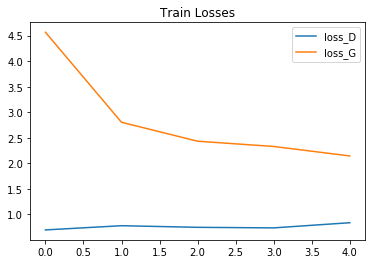

[5/25][0/383] Loss_D: 0.8147 Loss_G: 2.1708 D(x): 0.7744 D(G(z)): 0.3859 / 0.1398
[5/25][1/383] Loss_D: 0.8304 Loss_G: 1.8325 D(x): 0.6222 D(G(z)): 0.2442 / 0.1966
[5/25][2/383] Loss_D: 0.5987 Loss_G: 2.8642 D(x): 0.8490 D(G(z)): 0.3226 / 0.0772
[5/25][3/383] Loss_D: 0.7821 Loss_G: 1.5732 D(x): 0.5908 D(G(z)): 0.1647 / 0.2420
[5/25][4/383] Loss_D: 0.6638 Loss_G: 2.7551 D(x): 0.8564 D(G(z)): 0.3604 / 0.0841
[5/25][5/383] Loss_D: 0.6526 Loss_G: 1.9834 D(x): 0.6597 D(G(z)): 0.1521 / 0.1658
[5/25][6/383] Loss_D: 0.6911 Loss_G: 1.8868 D(x): 0.7273 D(G(z)): 0.2692 / 0.1970
[5/25][7/383] Loss_D: 0.8212 Loss_G: 2.9426 D(x): 0.7925 D(G(z)): 0.3796 / 0.0780
[5/25][8/383] Loss_D: 0.7235 Loss_G: 1.7117 D(x): 0.6220 D(G(z)): 0.1452 / 0.2141
[5/25][9/383] Loss_D: 0.6777 Loss_G: 2.0272 D(x): 0.8088 D(G(z)): 0.3377 / 0.1641
[5/25][10/383] Loss_D: 0.7680 Loss_G: 2.2519 D(x): 0.7280 D(G(z)): 0.3074 / 0.1382
[5/25][11/383] Loss_D: 0.9129 Loss_G: 1.7331 D(x): 0.6249 D(G(z)): 0.2741 / 0.2080
[5/25][12/383]

In [0]:
import matplotlib.pyplot as plt
train_losses_G = []
train_losses_D = []

for epoch in range(num_epochs):
    train_loss_D = 0
    train_loss_G = 0
    for i, data in enumerate(loader_train, 0):
        
        
        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################device
        # train with real
        model_D.zero_grad()
        real_cpu = data[0].to(device)
        batch_size = real_cpu.size(0)
        label = torch.full((batch_size,), real_label, device=device)

        output = model_D(real_cpu)
        errD_real = loss_function(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # train with fake
        noise = torch.randn(batch_size, latent_vector_size, 1, 1, device=device)
        fake = model_G(noise)
        label.fill_(fake_label)
        output = model_D(fake.detach())
        errD_fake = loss_function(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        train_loss_D += errD.item()
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        model_G.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        output = model_D(fake)
        errG = loss_function(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        train_loss_G += errG.item()
        optimizerG.step()

        
        print('[%d/%d][%d/%d] Loss_D: %.4f Loss_G: %.4f D(x): %.4f D(G(z)): %.4f / %.4f'
            % (epoch, num_epochs, i, len(loader_train),
                errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

    if epoch == 0:
        save_image(denorm(real_cpu.cpu()).float(), './CW_DCGAN/real_samples.png')
    
    fake = model_G(fixed_noise)
    save_image(denorm(fake.cpu()).float(), './CW_DCGAN/fake_samples_epoch_%03d.png' % epoch)
    train_losses_D.append(train_loss_D / len(loader_train))
    train_losses_G.append(train_loss_G / len(loader_train))

    if (epoch + 1) % 5 == 0:
        plt.plot(list(range(0, np.array(train_losses_D).shape[0])), np.array(train_losses_D), label='loss_D')
        plt.plot(list(range(0, np.array(train_losses_G).shape[0])), np.array(train_losses_G), label='loss_G')
        plt.legend()
        plt.title('Train Losses')
        plt.show()
    schedulerG.step()
# save models
torch.save(model_G.state_dict(), './CW_DCGAN/DCGAN_model_G.pth')
torch.save(model_D.state_dict(), './CW_DCGAN/DCGAN_model_D.pth')

In [0]:
# DISCUSS THE SELECTION OF THE ARCHITECTURE IN THIS CELL*


During training, we train two neural netwrorks; the Generator which given a random input sampled from the Normal distribution is trained to gererate images from our data (CIFAR-10) and the Discriminator which given the output of the Generator and the real images from our data, is trained to distinguish which are fake and which are real. 

After various trials (and many hours of training!!!) I have decided to use this architecture for each of the networks :

**Generator's Architecture:**
The Genarator takes in as an input a latent_dim x 1 x 1 noise vector, denoted z, and maps it into the G(Z) output which is 3 x 32 x 32, where 3 represents the number of output channels (which is the number of channels of a colored RGB image).

The idea of the implementation of the architecture of the generator was to apply hierarchical deconvolutions ("ConvTranspose2d") to the input, specifically (latent_dim x 1 x 1 --> 512 x 4 x 4 --> 256 x 8 x 8 --> 128 x 16 x 16 --> 3 x 32 x 32). Moreover, as a non-linearity in each of those layers (execpt the last) I use ReLU to overcome the curse of the vanishing gradients. As a non-linearity for the last layer, Tanh is used to push values within -1 and 1. Additonally, I used Batch Normalization after each convolutional layer, except the last one.

The latent dimension (100) was chosen after training the model using different choices of the latent_dim (50, **100**, 120, 200, 250, 300, 350).

**Descriminator's Architecture:**

The descriminator network has the typical convolutinal neural net structure. It receives an input of a shape of 3 x 32 x 32 (reconstructed image or original image). It is consisted of 4 convolutional layers. Instead of ReLU, LeakyReLU is used since it allows the descriminator to pass small gradients for negative inputs to the generator which helps the generator to reconstruct faster and more effectively the images. Moreover, "BatchNorm" is also used here for all the layers except the output layer. After several trials without using it, the Generator fell into mode collapse, i.e. it generated similar outputs for different random inputs.

Since we want to use the descriminator as a classifier {0 : fake, 1 : real}, for its last layer I used as an activation the sigmoid function which pushed inputs between 0 and 1 (probability-like).


--------------------------------------



### Generator samples

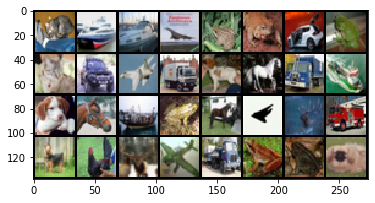

In [0]:
it = iter(loader_test)
sample_inputs, _ = next(it)
fixed_input = sample_inputs[:32, :, :, :]

# visualize the original images of the last batch of the test set
img = make_grid(denorm(fixed_input), nrow=8, padding=2, normalize=False,
                range=None, scale_each=False, pad_value=0)
show(img)

In [0]:
# load the model
model_G = Generator().to(device)
model_G.load_state_dict(torch.load('./CW_DCGAN/DCGAN_model_G.pth'))
input_noise = torch.randn(batch_size, latent_vector_size, 1, 1, device=device)

with torch.no_grad():
    # visualize the generated images
    generated = model_G(input_noise).cpu()
    generated = make_grid(denorm(generated)[:32], nrow=8, padding=2, normalize=False, 
                        range=None, scale_each=False, pad_value=0)
    show(generated)
    

RuntimeError: ignored

### Part 2.2 (10 points)

### Train losses curves
**Your task:**


Plot the losses curves for the discriminator $D$ and the generator $G$ as the training progresses and explain whether the produced curves are theoretically sensible and why this is (or not) the case (x-axis: epochs, y-axis: loss).

The code for generating the plot is already given. Make sure that the version of the notebook you deliver includes these results.

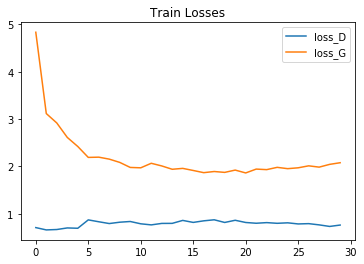

In [0]:
import matplotlib.pyplot as plt
plt.plot(list(range(0, np.array(train_losses_D).shape[0])), np.array(train_losses_D), label='loss_D')
plt.plot(list(range(0, np.array(train_losses_G).shape[0])), np.array(train_losses_G), label='loss_G')
plt.legend()
plt.title('Train Losses')
plt.show()


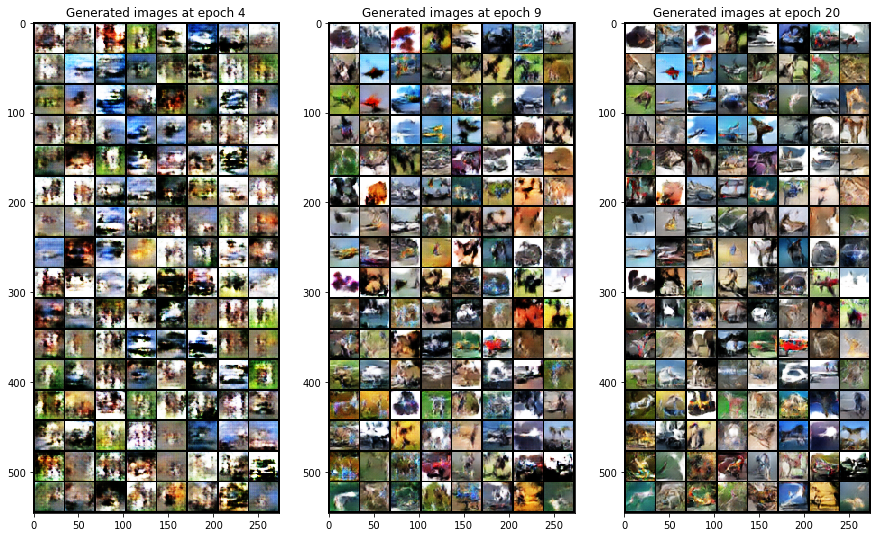

In [0]:
# ANSWER FOR PART 2.2 IN THIS CELL*
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img04 = mpimg.imread('./CW_DCGAN/fake_samples_epoch_003.png')
img10 = mpimg.imread('./CW_DCGAN/fake_samples_epoch_009.png')
img20 = mpimg.imread('./CW_DCGAN/fake_samples_epoch_019.png')
plt.figure(1,figsize=(15,10))
plt.subplot(131)
plt.title('Generated images at epoch 4')
plt.imshow(img04)
plt.subplot(132)
plt.title('Generated images at epoch 9')
plt.imshow(img10)
plt.subplot(133)
plt.title('Generated images at epoch 20')
plt.imshow(img20)
plt.show()


As can be observed from the plotted loss graphs, the loss of the Generator dropped significally from the very first epochs. That was expected; after each backpropagation, the weigths of each layer of the generator are updated, and the generator learns to reproduce the the data, given the random noise. As we can see from the two pictures above, indeed the generator after 9 and 26 epochs has learnt to generate the data significally better compared to after 4 epochs. The generated images at the 26-th epoch look similar to the original data, whilst at the 4-th epoch we can't really infer what the generated pictures show.

On the other hand, the loss of the discriminator remains relatively small throughout the whole training. However, we can notice an increase of the discriminator's loss especially at times when the loss of the generator drops. It increases and stabilizes around 0.5. Of course, that was expected as well, since this is an adversarial 'game'; when the generator learns to produce our data well, it's inevidable that this will make the job of the discriminator harder!

Ideally, after many epochs of training (maybe more than 100), the losses of the two networks will converge to the same number, as the generator will learn how to generate pictures sampled from our training distribution, whilst the discriminator will not be able to distinguish which images are fake or not!

### Part 2.3 (10 points) 
**Your task:** 

Based on the images created by your generator using the `fixed_noise` vector during training, provide a discussion on whether you noticed any mode collapse, where this behaviour may be attributed to, and explain what you did in order to cope with mode collapse.

In [0]:
# ANSWER FOR PART 2.3 IN THIS CELL*



Before deciding the final architecture of the models, at my first trials of implimenting the networks of the generator and the discriminator, when I plotted the generated samples of the generator had low variety and they looked simillar. 
This is called mode collapse; Mode collapse is when the generator outputs limited varieties of samples, which cannot capture enough "modes" of data features.

Since this is an adversarial (min-max) game, the two losses of the two networks will eventually converge . If the generator becomes so good at generating a small set  of samples that are virtually indistinguishable from the real data, this will actually fool the discriminator every time. So mode collapse happens when it’s easier for the generator network to generate a sample(s) which look(s) real and fool the discriminator, i.e to pick an $\overline{x}=G(z)=\arg \max D(x)$ in order to minimise $\mathbb{E}_{z \sim p(z)}[\log(1-D(G(z)))]$

To tackle this problem, I tried training the two networks with various parameters, (number of filters on each layer, tried transforming the input images, etc) and trained on more epochs. Additionally, I tried using a lower learning rate (0.0002) than the one I used initially(0.001).
Moreover, what certainly helped is the fact that  I used a Batch normalization after each layer of both, the generator and the discriminator. What batch normalization does, is normalise the input features of the layer to have zero mean and unit variance. Therefore, normalization helps remove dependancies.

A nice idea would be to train multiple generators, and let each one focus on a different class!
